In [1]:
# q16
# Cell 1: Import Libraries and Load Dataset
import pandas as pd
import numpy as np
import math
from pprint import pprint

# Load the dataset
# Make sure to place 'play_tennis.csv' in the current working directory, 
# or specify the correct file path.
try:
    data = pd.read_csv('play_tennis.csv')
    print("Dataset loaded successfully:")
    print(data.head())
except FileNotFoundError:
    print("Error: play_tennis.csv not found.")
    print("Please download the dataset (e.g., from [GitHub](https://github.com/profthyagu/Python-Decision-Tree-Using-ID3/blob/master/PlayTennis.csv)) and place it in the correct directory.")
    exit()


Dataset loaded successfully:
  day   outlook  temp humidity    wind play
0  D1     Sunny   Hot     High    Weak   No
1  D2     Sunny   Hot     High  Strong   No
2  D3  Overcast   Hot     High    Weak  Yes
3  D4      Rain  Mild     High    Weak  Yes
4  D5      Rain  Cool   Normal    Weak  Yes


In [5]:
# Cell 2: Define Entropy Calculation Function
def entropy(target_col):
    """
    Calculates the entropy of the target column.
    """
    elements, counts = np.unique(target_col, return_counts=True)
    entropy_val = -np.sum([(counts[i]/np.sum(counts)) * math.log2(counts[i]/np.sum(counts)) for i in range(len(elements))])
    return entropy_val

# Example usage (optional):
print(f"\nInitial Entropy of the dataset: {entropy(data['play'])}")



Initial Entropy of the dataset: 0.9402859586706311


In [6]:
# Cell 3: Define Information Gain Calculation Function
def info_gain(data, feature_attribute_name, target_attribute_name="play"):
    """
    Calculates the information gain of a feature.
    """
    # Calculate the entropy of the whole dataset
    total_entropy = entropy(data[target_attribute_name])
    
    # Calculate the weighted entropy of each feature value
    values, counts = np.unique(data[feature_attribute_name], return_counts=True)
    weighted_entropy = np.sum([(counts[i]/np.sum(counts)) * entropy(data.where(data[feature_attribute_name]==values[i]).dropna()[target_attribute_name]) for i in range(len(values))])
    
    # Calculate information gain
    information_gain = total_entropy - weighted_entropy
    return information_gain

# Example usage (optional):
for col in data.columns[:-1]:
    print(f"Information Gain for '{col}': {info_gain(data, col)}")


Information Gain for 'day': 0.9402859586706311
Information Gain for 'outlook': 0.24674981977443933
Information Gain for 'temp': 0.02922256565895487
Information Gain for 'humidity': 0.15183550136234159
Information Gain for 'wind': 0.04812703040826949


In [7]:
# Cell 4: Define the ID3 Decision Tree Building Function
def build_tree(data, original_data, features, target_attribute_name="play", parent_node_class=None):
    """
    Builds the decision tree using the ID3 algorithm recursively.
    """
    # Stopping conditions
    # If all target values are the same, return that value as a leaf node
    if len(np.unique(data[target_attribute_name])) <= 1:
        return np.unique(data[target_attribute_name])[0]
    # If no features are left, return the majority class of the parent node
    elif len(features) == 0:
        return parent_node_class
    # If the current dataset is empty, return the majority class of the original data
    elif data.empty:
        return np.unique(original_data[target_attribute_name])[np.argmax(np.unique(original_data[target_attribute_name], return_counts=True)[1])]
    
    # Select the best feature with the highest information gain
    gains = [info_gain(data, feature, target_attribute_name) for feature in features]
    best_feature_index = np.argmax(gains)
    best_feature = features[best_feature_index]
    
    # Create the tree structure (dictionary)
    tree = {best_feature: {}}
    
    # Remove the best feature from the list of features for the next recursive call
    remaining_features = [i for i in features if i != best_feature]
    
    # Get the majority class for the current node (used as default if a branch is empty)
    parent_node_class = np.unique(data[target_attribute_name])[np.argmax(np.unique(data[target_attribute_name], return_counts=True)[1])]
    
    # Recurse for each unique value of the best feature
    for value in np.unique(data[best_feature]):
        sub_data = data.where(data[best_feature] == value).dropna()
        subtree = build_tree(sub_data, original_data, remaining_features, target_attribute_name, parent_node_class)
        tree[best_feature][value] = subtree
        
    return tree


In [8]:
# Cell 5: Build and Print the Decision Tree
features = list(data.columns[:-1])
decision_tree = build_tree(data, data, features)

print("\n\nThe Resultant Decision Tree is:")
pprint(decision_tree)




The Resultant Decision Tree is:
{'day': {'D1': 'No',
         'D10': 'Yes',
         'D11': 'Yes',
         'D12': 'Yes',
         'D13': 'Yes',
         'D14': 'No',
         'D2': 'No',
         'D3': 'Yes',
         'D4': 'Yes',
         'D5': 'Yes',
         'D6': 'No',
         'D7': 'Yes',
         'D8': 'No',
         'D9': 'Yes'}}


In [9]:
# Cell 6: Define Classification Function for a New Sample
def classify_sample(sample, tree):
    """
    Classifies a new sample using the built decision tree.
    """
    attribute = list(tree.keys())[0]
    value = sample[attribute]
    subtree = tree[attribute][value]
    
    if isinstance(subtree, dict):
        return classify_sample(sample, subtree)
    else:
        return subtree


In [11]:
# Cell 7: Classify a New Sample
# Define the new sample to classify
# Example 1: Sunny, Cool, High, Strong -> Expected: No (from the data D6/D8 logic)
new_sample1 = {'outlook': 'Sunny', 'temp': 'Cool', 'humidity': 'High', 'wind': 'Strong','day':'D1'}
# Example 2: Overcast, Mild, Normal, Weak -> Expected: Yes (from the data D13 logic)
new_sample2 = {'outlook': 'Overcast', 'temp': 'Mild', 'humidity': 'Normal', 'wind': 'Weak','day':'D2'}

# Classify the samples
result1 = classify_sample(new_sample1, decision_tree)
result2 = classify_sample(new_sample2, decision_tree)

print(f"\n\nClassification Result for Sample 1 {new_sample1}: {result1}")
print(f"Classification Result for Sample 2 {new_sample2}: {result2}")




Classification Result for Sample 1 {'outlook': 'Sunny', 'temp': 'Cool', 'humidity': 'High', 'wind': 'Strong', 'day': 'D1'}: No
Classification Result for Sample 2 {'outlook': 'Overcast', 'temp': 'Mild', 'humidity': 'Normal', 'wind': 'Weak', 'day': 'D2'}: No


In [12]:
# q17
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [13]:
# Load dataset
data = pd.read_csv("iris.csv")

# Show first 5 rows
print(data.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [14]:
# Features (independent variables)
X = data.iloc[:, :-1].values   # all columns except last

# Target (dependent variable)
y = data.iloc[:, -1].values    # last column

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% test data
    random_state=42     # for reproducibility
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 105
Testing samples: 45


In [17]:
# Create model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)



,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [18]:
# Predict on test data
y_pred = model.predict(X_test)

print("Predictions:", y_pred[:10])

Predictions: ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']


In [19]:
# Example test samples
sample_data = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.7, 3.0, 5.2, 2.3],
    [5.9, 3.2, 4.8, 1.8]
])

sample_pred = model.predict(sample_data)

print("Custom Sample Predictions:", sample_pred)

Custom Sample Predictions: ['setosa' 'virginica' 'virginica']


In [20]:
# q18
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [21]:
# Load dataset
data = pd.read_csv("iris.csv")

# Preview data
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [22]:
# Features (all columns except last)
X = data.iloc[:, :-1].values

# Target (last column)
y = data.iloc[:, -1].values

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 105
Testing samples: 45


In [25]:
# Create KNN classifier (k = 3 neighbors)
knn = KNeighborsClassifier(n_neighbors=3)

# Train model
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [26]:
# Predict on test data
y_pred = knn.predict(X_test)

print("Predictions:", y_pred[:10])

Predictions: ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']


In [27]:
correct = []
wrong = []

for actual, predicted in zip(y_test, y_pred):
    if actual == predicted:
        correct.append((actual, predicted))
    else:
        wrong.append((actual, predicted))

print("Total Test Samples:", len(y_test))
print("Correct Predictions:", len(correct))
print("Wrong Predictions:", len(wrong))

print("\nSome Correct Predictions (Actual, Predicted):")
print(correct[:10])

print("\nSome Wrong Predictions (Actual, Predicted):")
print(wrong[:10])

Total Test Samples: 45
Correct Predictions: 45
Wrong Predictions: 0

Some Correct Predictions (Actual, Predicted):
[('versicolor', 'versicolor'), ('setosa', 'setosa'), ('virginica', 'virginica'), ('versicolor', 'versicolor'), ('versicolor', 'versicolor'), ('setosa', 'setosa'), ('versicolor', 'versicolor'), ('virginica', 'virginica'), ('versicolor', 'versicolor'), ('versicolor', 'versicolor')]

Some Wrong Predictions (Actual, Predicted):
[]


In [30]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of KNN Classifier: {:.2f}%".format(accuracy*100))

Accuracy of KNN Classifier: 100.00%


In [31]:
# q19
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [33]:
data = pd.read_csv("HousingData.csv")
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [40]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X = data.drop("MEDV", axis=1)
y = data["MEDV"]

X = imputer.fit_transform(X)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred_lin = lin_reg.predict(X_test)
print("First 10 Predictions:", y_pred_lin[:10])

First 10 Predictions: [29.48758967 16.89843072 21.88395113 30.03140416 18.33998157 34.41717332
 22.29567579 30.18541478 32.68800811 15.15148614]


In [43]:
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression MSE:", mse_lin)
print("Linear Regression R²:", r2_lin)

Linear Regression MSE: 28.870771928253507
Linear Regression R²: 0.6905175764205989


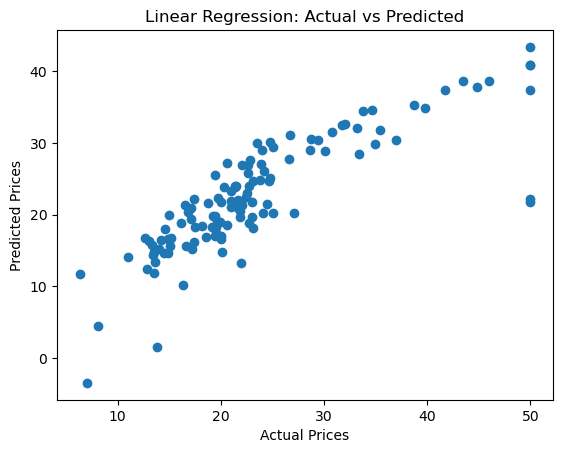

In [44]:
plt.scatter(y_test, y_pred_lin)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [45]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [46]:
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
y_pred_poly = poly_reg.predict(X_test_poly)
print("First 10 Predictions:", y_pred_poly[:10])

First 10 Predictions: [27.51492539 24.80499252 20.70674869 28.56886984 20.10866369 35.22462831
 20.70362768 27.96634724 32.46473689 11.3532341 ]


In [48]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression MSE:", mse_poly)
print("Polynomial Regression R²:", r2_poly)

Polynomial Regression MSE: 19.78047606239399
Polynomial Regression R²: 0.7879616905790733


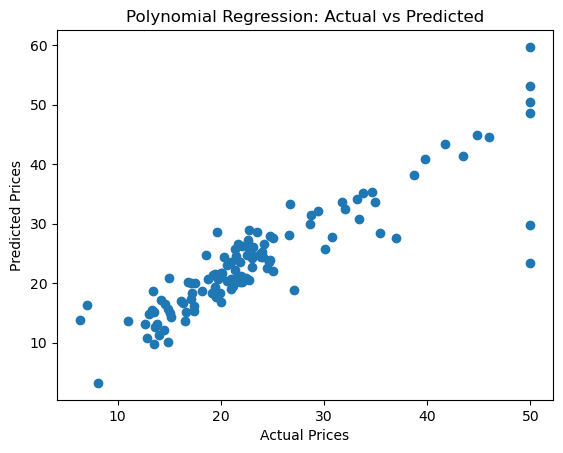

In [49]:
plt.scatter(y_test, y_pred_poly)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.show()